## Импорты библиотек

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns

from datasets import load_dataset
from IPython.display import display

### Версии библиотек

In [2]:
packages = [
    "NumPy", "Pandas", "Polars", "Matplotlib", "Seaborn", "Datasets",
]
package_objects = [
    np, pd, pl, mpl, sns, __import__("datasets"),
]

versions = [obj.__version__ for obj in package_objects]

columns_order = ["№", "Библиотека", "Версия"]

df_pkgs = (
    pl.DataFrame({
        columns_order[1]: packages,
        columns_order[2]: versions,
    })
    .with_columns(
        pl.arange(1, pl.lit(len(packages)) + 1).alias(columns_order[0])
    )
    .select(columns_order)
)

display(df_pkgs)

№,Библиотека,Версия
i64,str,str
1,"""NumPy""","""2.0.2"""
2,"""Pandas""","""2.2.2"""
3,"""Polars""","""1.35.2"""
4,"""Matplotlib""","""3.10.0"""
5,"""Seaborn""","""0.13.2"""
6,"""Datasets""","""4.0.0"""


### создание requirements.txt

In [ ]:
path2reqs = "."
reqs_name = "requirements.txt"

def get_packages_and_versions():
    """Генерация строк библиотека==версия для requirements.txt."""
    for pkg, ver in zip(packages, versions):
        yield f"{pkg.lower()}=={ver}\n"

with open(os.path.join(path2reqs, reqs_name), "w", encoding="utf-8") as f:
    f.writelines(get_packages_and_versions())

print("requirements.txt сохранён")

## Константы

Таксономия меток эмоций

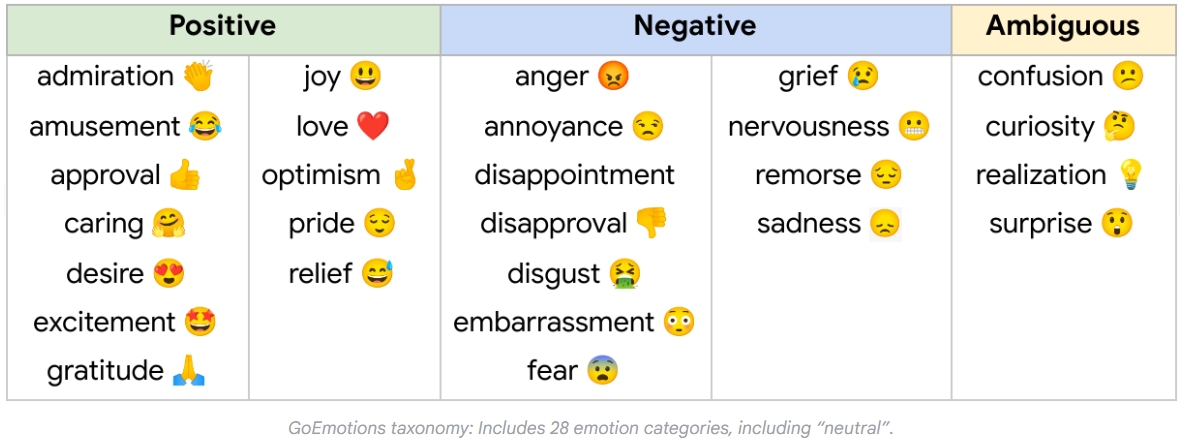

In [3]:
# Папки для артефактов
EDA_DIR  = "eda"
DATA_DIR = "data"
os.makedirs(EDA_DIR,  exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Порог для редкого класса
RARE_THRESHOLD = 500

# Список 28 эмоций в GoEmotions
EMOTIONS = [
    "admiration", "amusement", "approval", "caring", "desire",
    "excitement","gratitude", "joy",  "love", "optimism",
    "pride", "relief", "anger", "annoyance", "disappointment",
    "disapproval", "disgust", "embarrassment",  "fear", "grief",
    "nervousness", "remorse", "sadness", "confusion", "curiosity",
    "realization",   "surprise", "neutral",
]

NUM_EMOTIONS = len(EMOTIONS)  # 28

# Стиль графиков
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE_MAIN = "#1f77b4"
PALETTE_RARE = "#d62728"

print(f"Эмоций: {NUM_EMOTIONS}")
print(f"Список: {EMOTIONS}")

Эмоций: 28
Список: ['admiration', 'amusement', 'approval', 'caring', 'desire', 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief', 'anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness', 'confusion', 'curiosity', 'realization', 'surprise', 'neutral']


## Загрузка датасета (simplified версия)

> - Каждый текст - одна строка  
> - `labels` - список индексов эмоций, набравших **≥ 2 голосов** аннотаторов

In [4]:
print("Загрузка GoEmotions (simplified)")
dataset = load_dataset("go_emotions", "simplified")
print(dataset)

Загрузка GoEmotions (simplified)


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


### Примеры

In [5]:
print("Примеры (text + label indices)")
for i in range(10):
    item  = dataset["train"][i]
    emots = [EMOTIONS[idx] for idx in item["labels"]]
    print(f"[{i + 1}] {item['text']}")
    print(f"labels (idx): {item['labels']}: {emots}\n")

Примеры (text + label indices)
[1] My favourite food is anything I didn't have to cook myself.
labels (idx): [27]: ['neutral']

[2] Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
labels (idx): [27]: ['neutral']

[3] WHY THE FUCK IS BAYLESS ISOING
labels (idx): [2]: ['approval']

[4] To make her feel threatened
labels (idx): [14]: ['disappointment']

[5] Dirty Southern Wankers
labels (idx): [3]: ['caring']

[6] OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.
labels (idx): [26]: ['surprise']

[7] Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝
labels (idx): [15]: ['disapproval']

[8] We need more boards and to create a bit more space for [NAME]. Then we’ll be good.
labels (idx): [8, 20]: ['love', 'nervousness']

[9] Damn youtube and outrage drama is super lucrative for reddit
labels (idx): [0]: ['admirat

## Конвертация в pandas и сохранение CSV

In [7]:
def hf_split_to_df(hf_split) -> pd.DataFrame:
    """
    Конвертирует HuggingFace Dataset -> pandas DataFrame.

    Каждая эмоция становится отдельным бинарным столбцом:
      1 — эмоция присутствует в примере
      0 — отсутствует

    Параметры
    ----------
    hf_split : datasets.Dataset  (один сплит: train / val / test)

    Возвращает
    ----------
    pd.DataFrame:  id | text | admiration | amusement | ... | neutral
    """
    records = []
    for item in hf_split:
        row = {"id": item["id"], "text": item["text"]}
        vec = [0] * NUM_EMOTIONS
        for idx in item["labels"]:
            vec[idx] = 1
        for emo, val in zip(EMOTIONS, vec):
            row[emo] = val
        records.append(row)
    return pd.DataFrame(records)

In [10]:
df_train = hf_split_to_df(dataset["train"])
df_val = hf_split_to_df(dataset["validation"])
df_test = hf_split_to_df(dataset["test"])

print("Размеры сплитов:")
print(f"train : {df_train.shape}")
print(f"val: {df_val.shape}")
print(f"test: {df_test.shape}")

Размеры сплитов:
train : (43410, 30)
val: (5426, 30)
test: (5427, 30)


In [12]:
df_train.to_csv(os.path.join(DATA_DIR, "train.csv"), index=False)
df_val.to_csv(os.path.join(DATA_DIR, "val.csv"),   index=False)
df_test.to_csv(os.path.join(DATA_DIR, "test.csv"),  index=False)

print("data/train.csv, data/val.csv, data/test.csv сохранены")

data/train.csv, data/val.csv, data/test.csv сохранены


In [13]:
print("Примеры из DataFrame")
for _, row in df_train.head(5).iterrows():
    active = [e for e in EMOTIONS if row[e] == 1]
    print(f"{row['text']}")
    print(f"эмоции: {active}\n")

Примеры из DataFrame
My favourite food is anything I didn't have to cook myself.
эмоции: ['neutral']

Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
эмоции: ['neutral']

WHY THE FUCK IS BAYLESS ISOING
эмоции: ['approval']

To make her feel threatened
эмоции: ['disappointment']

Dirty Southern Wankers
эмоции: ['caring']



## Базовая статистика

In [14]:
n_total  = len(df_train)
n_unique = df_train["text"].nunique()
n_empty  = df_train["text"].isna().sum() + (df_train["text"] == "").sum()

print(f"Всего примеров: {n_total}")
print(f"Уникальных текстов: {n_unique}")
print(f"Дублирующихся текстов: {n_total - n_unique}")
print(f"Пустых текстов: {n_empty}")

Всего примеров: 43410
Уникальных текстов: 43227
Дублирующихся текстов: 183
Пустых текстов: 0


In [15]:
# Количество меток на каждый пример
label_counts = df_train[EMOTIONS].sum(axis=1)

print(f"Среднее меток на пример: {label_counts.mean():.3f}")
print(f"Максимум меток: {label_counts.max()}")
print(f"Примеров без метки: {(label_counts == 0).sum()}")

Среднее меток на пример: 1.177
Максимум меток: 5
Примеров без метки: 0


In [16]:
# Частота каждой эмоции + редкие классы
emotion_freq  = df_train[EMOTIONS].sum().sort_values(ascending=False)
rare_emotions = emotion_freq[emotion_freq < RARE_THRESHOLD]

print(f"Редких классов (< {RARE_THRESHOLD}): {len(rare_emotions)}")
print(f"Самый частый класс: {emotion_freq.index[0]}  ({emotion_freq.iloc[0]})")
print(f"Самый редкий класс: {emotion_freq.index[-1]} ({emotion_freq.iloc[-1]})")

Редких классов (< 500): 5
Самый частый класс: neutral  (14219)
Самый редкий класс: disgust (77)


## Раздел 7 — Графики

### Распределение классов

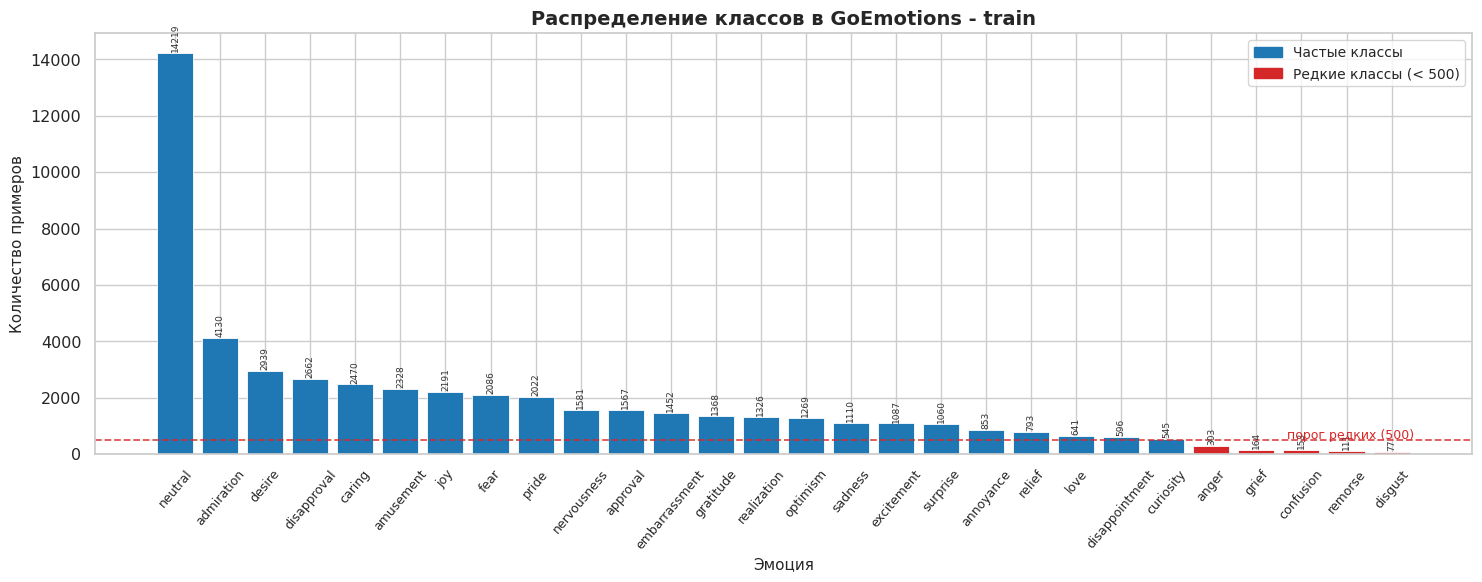

eda/01_class_distribution.png


In [17]:
fig, ax = plt.subplots(figsize=(15, 6))

colors = [
    PALETTE_RARE if emotion_freq[emo] < RARE_THRESHOLD else PALETTE_MAIN
    for emo in emotion_freq.index
]
bars = ax.bar(
    emotion_freq.index, emotion_freq.values,
    color=colors, edgecolor="white", linewidth=0.6,
)
for bar, val in zip(bars, emotion_freq.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
        str(int(val)),
        ha="center", va="bottom", fontsize=6.5, rotation=90, color="#333",
    )
ax.axhline(RARE_THRESHOLD, color=PALETTE_RARE, linestyle="--", linewidth=1.3, alpha=0.8)
ax.text(len(emotion_freq) - 0.5, RARE_THRESHOLD + 60,
        f"порог редких ({RARE_THRESHOLD})", ha="right", color=PALETTE_RARE, fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color=PALETTE_MAIN, label="Частые классы"),
    mpatches.Patch(color=PALETTE_RARE, label=f"Редкие классы (< {RARE_THRESHOLD})"),
], fontsize=10)
ax.set_title("Распределение классов в GoEmotions - train", fontsize=14, fontweight="bold")
ax.set_xlabel("Эмоция", fontsize=11)
ax.set_ylabel("Количество примеров", fontsize=11)
ax.tick_params(axis="x", rotation=50, labelsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "01_class_distribution.png"), dpi=150)
plt.show()
print("eda/01_class_distribution.png")

### Доля примеров по числу меток

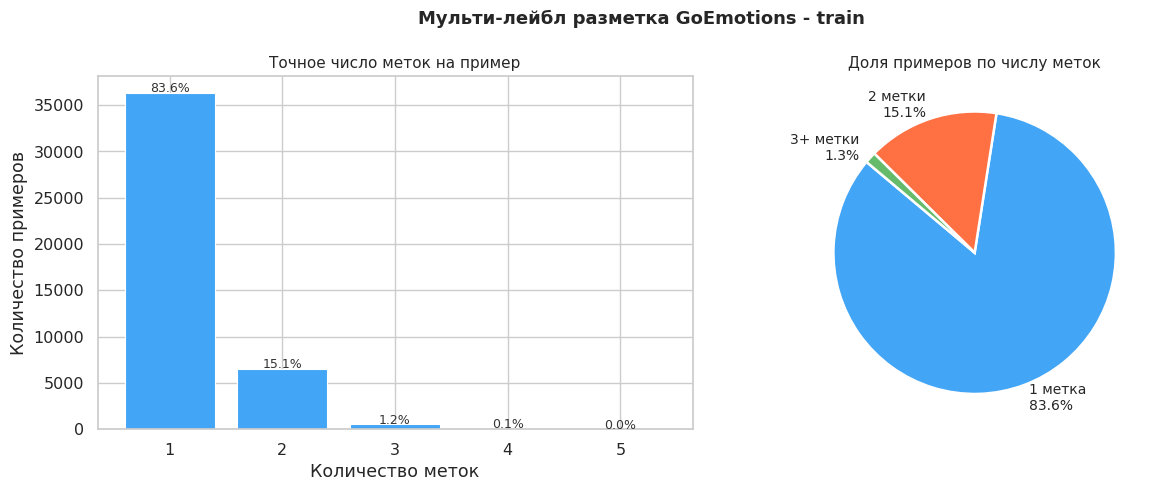

eda/02_multilabel_distribution.png


In [18]:
distribution = label_counts.value_counts().sort_index()
one = (label_counts == 1).sum()
two = (label_counts == 2).sum()
three = (label_counts >= 3).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Мульти-лейбл разметка GoEmotions - train", fontsize=13, fontweight="bold")

ax = axes[0]
ax.bar(distribution.index.astype(str), distribution.values, color="#42A5F5", edgecolor="white", linewidth=0.8)
for i, (n, v) in enumerate(zip(distribution.index, distribution.values)):
    ax.text(i, v + 80, f"{v / n_total * 100:.1f}%", ha="center", fontsize=9, color="#333")
ax.set_title("Точное число меток на пример", fontsize=11)
ax.set_xlabel("Количество меток")
ax.set_ylabel("Количество примеров")

axes[1].pie(
    [one, two, three],
    labels=[
        f"1 метка\n{one/n_total*100:.1f}%",
        f"2 метки\n{two/n_total*100:.1f}%",
        f"3+ метки\n{three/n_total*100:.1f}%",
    ],
    colors=["#42A5F5", "#FF7043", "#66BB6A"],
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.8},
    textprops={"fontsize": 10},
)
axes[1].set_title("Доля примеров по числу меток", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "02_multilabel_distribution.png"), dpi=150)
plt.show()
print("eda/02_multilabel_distribution.png")

In [25]:
print(label_counts.value_counts().sort_index())

1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64


### Матрица совместной встречаемости

> `co_matrix[i, j]` = число примеров train, где одновременно присутствуют эмоция **i** и **j**.  
> `co_norm[i, j]` = P(j | i) - насколько часто j встречается вместе с i (нормированная версия).

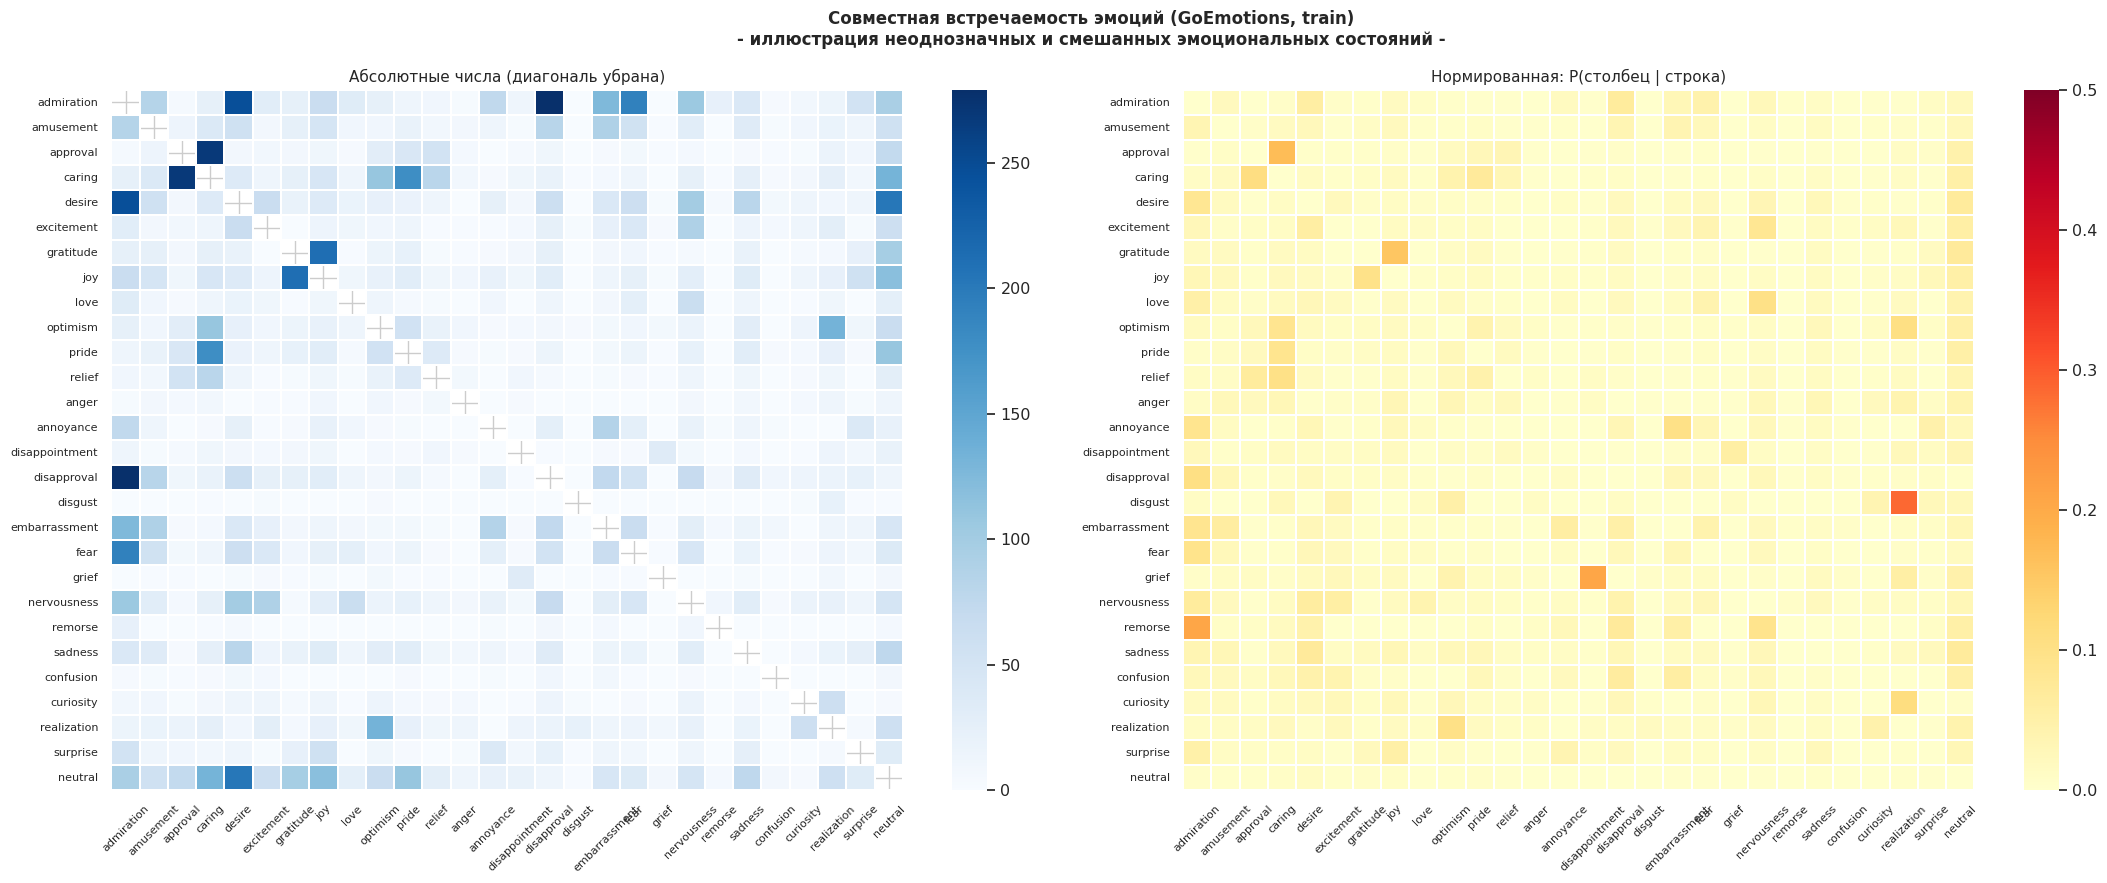

eda/03_cooccurrence_matrix.png


In [21]:
label_matrix = df_train[EMOTIONS].values
co_matrix = label_matrix.T @ label_matrix   # (28, 28)

freq = np.diag(co_matrix).astype(float)
with np.errstate(divide="ignore", invalid="ignore"):
    co_norm = co_matrix / freq[:, None]
co_norm = np.nan_to_num(co_norm)
np.fill_diagonal(co_norm, 0)

co_no_diag = co_matrix.astype(float).copy()
np.fill_diagonal(co_no_diag, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(
    "Совместная встречаемость эмоций (GoEmotions, train)\n"
    "- иллюстрация неоднозначных и смешанных эмоциональных состояний -",
    fontsize=12, fontweight="bold",
)
sns.heatmap(pd.DataFrame(co_no_diag, index=EMOTIONS, columns=EMOTIONS),
    ax=axes[0], cmap="Blues", linewidths=0.25, linecolor="white",
    annot=False, xticklabels=True, yticklabels=True)
axes[0].set_title("Абсолютные числа (диагональ убрана)", fontsize=11)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

sns.heatmap(pd.DataFrame(co_norm, index=EMOTIONS, columns=EMOTIONS),
    ax=axes[1], cmap="YlOrRd", vmin=0, vmax=0.5,
    linewidths=0.25, linecolor="white",
    annot=False, xticklabels=True, yticklabels=True)
axes[1].set_title("Нормированная: P(столбец | строка)", fontsize=11)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "03_cooccurrence_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("eda/03_cooccurrence_matrix.png")

### Топ-15 пар эмоций

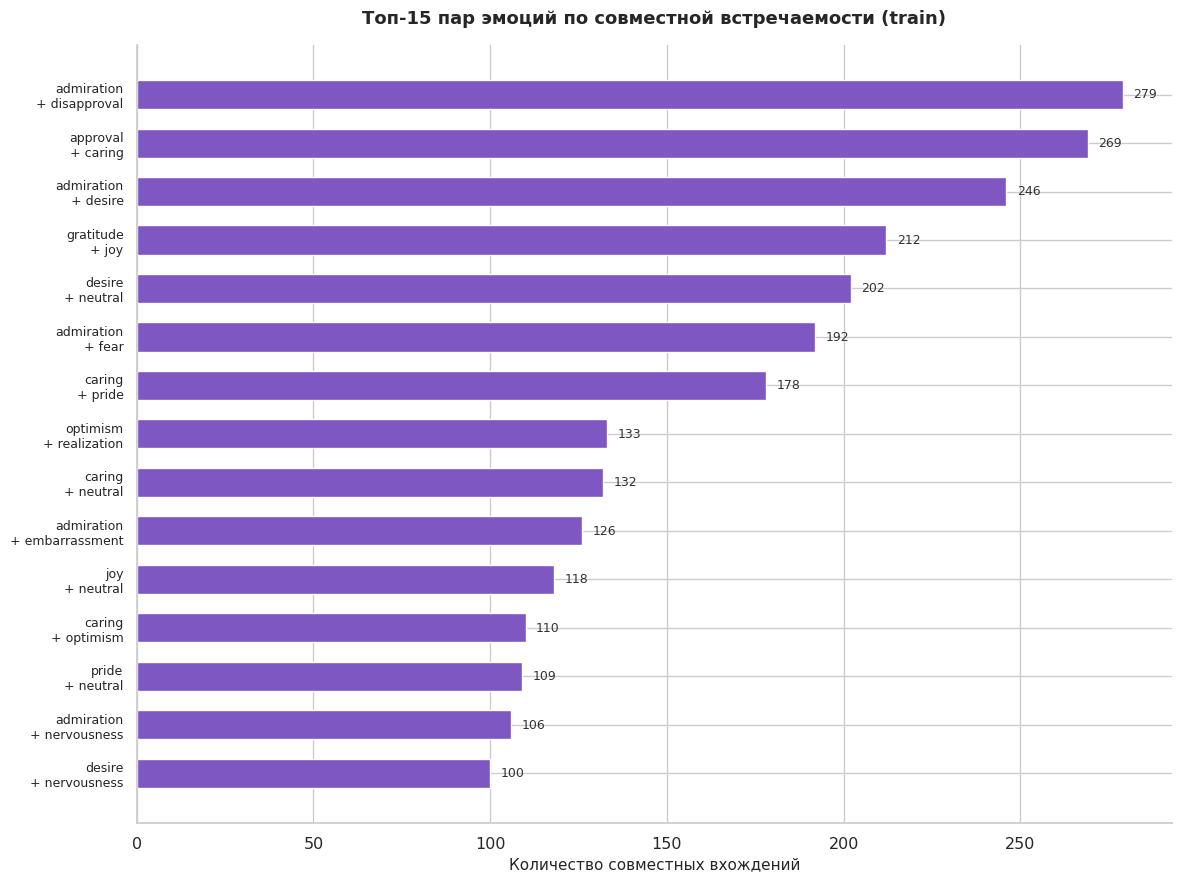

In [24]:
top15 = df_pairs.head(15).copy()

top15["Пара"] = top15["Эмоция 1"] + "\n+ " + top15["Эмоция 2"]

fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    top15["Пара"][::-1],
    top15["Совм. встречаемость"][::-1],
    color="#7E57C2",
    edgecolor="white",
    height=0.6,
)

for bar, val in zip(bars, top15["Совм. встречаемость"][::-1]):
    ax.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        str(int(val)),
        va="center", ha="left", fontsize=9, color="#333",
    )

ax.set_title(
    "Топ-15 пар эмоций по совместной встречаемости (train)",
    fontsize=13, fontweight="bold", pad=15,
)
ax.set_xlabel("Количество совместных вхождений", fontsize=11)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.tick_params(axis="y", labelsize=9)

plt.subplots_adjust(left=0.22)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "04_top_pairs.png"), dpi=150, bbox_inches="tight")
plt.show()

### Примеры неоднозначных высказываний

In [23]:
# Тексты с 2+ метками
multi_df = df_train[label_counts >= 2].copy()
multi_df["active_emotions"] = multi_df[EMOTIONS].apply(
    lambda row: [e for e in EMOTIONS if row[e] == 1], axis=1
)
multi_df["n_labels"] = multi_df[EMOTIONS].sum(axis=1)

print(f"Примеров с 2+ эмоциями: {len(multi_df)}\n")
print("Примеры неоднозначных высказываний \n")
for _, row in multi_df.head(10).iterrows():
    print(f"{row['text']}")
    print(f"эмоции ({int(row['n_labels'])}): {row['active_emotions']}\n")

Примеров с 2+ эмоциями: 7102

Примеры неоднозначных высказываний 

We need more boards and to create a bit more space for [NAME]. Then we’ll be good.
эмоции (2): ['love', 'nervousness']

Aww... she'll probably come around eventually, I'm sure she was just jealous of [NAME]... I mean, what woman wouldn't be! lol 
эмоции (2): ['amusement', 'desire']

Shit, I guess I accidentally bought a Pay-Per-View boxing match
эмоции (2): ['caring', 'anger']

Maybe that’s what happened to the great white at Houston zoo
эмоции (2): ['gratitude', 'sadness']

I never thought it was at the same moment, but sometimes after [NAME] sacrifice... sounds logical
эмоции (3): ['gratitude', 'optimism', 'neutral']

I miss them being alive
эмоции (2): ['disgust', 'realization']

Ok, then what the actual fuck is your plan?
эмоции (2): ['approval', 'joy']

aw, thanks! I appreciate that! 
эмоции (2): ['admiration', 'disapproval']

Thanks! I love watching him every week
эмоции (2): ['disapproval', 'fear']

I read on a d